# Global Household Financial Health - EDA, Prediction & Regional Analysis

A data science pipeline: 
* explore how income, debt, savings and employment shape financial health across 5 global regions,
* then build ML models to predict financial stress and credit scores,
* And cluster households by financial behaviour.

**Dataset:** 
* Household_ID
* Country: 5 global regions
* City
* Family_Size
* Num_Earners
* Primary_Income
* Total_Household_Income
* Estimated_Taxes
* Monthly_Expenses
* Monthly_Savings

**Business Questions:**
1. Household income distribution - How is household income distributed globally, and which countries have the highest and lowest earning households? - EDA
2. Households vs savings rate and expense rate? - EDA
3. Does having more earners in a household affect income per capita? - EDA
4. Is there a statistically significant difference in savings rates across countries — or is the variation just random noise? - Hypothesis
5. Does larger families have lower standard of living (income_per_capita)? - Hypothesis
6. Does multiple earners households have different spending rate? - Hypothesis
7. What drives monthly savings - income, family size, number of earners and expenses? - OLS Regression
8. Can we accurately predict whether a household will fall into Low, Medium or High financial health — before knowing their savings or expenses? - Supervised ML - Classification
9. Which household characteristics are the strongest predictors of financial health — is it income, family size, tax burden, or spending behaviour? - Feature importance for each classification model
10. What causes a household to fall into poor health? - SHAP explainability
11. How accurately can we predict a household's monthly savings? - Supervised ML - Regression
12. Do households naturally cluster into distinct financial profiles? - Unsupervised ML - K-Means - Silhouette score
13. What share of the global household population is at financial risk? - Unsupervised ML - K-Means - Cluster Profiling
14. Which countries and family structures are most over-represented in the vulnerable segment? - Unsupervised ML - K-Means - Cluster Analysis


### Import packages

In [350]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin
import shap
from scipy.stats import f_oneway, pearsonr
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import adjusted_rand_score

### Import dataset

In [280]:
household = pd.read_csv('C:\\Users\\shrey\\JupyterNotebook\\Global_Household_Analysis\\dataset\\Global_Household_Financial_Dynamics.csv')
display(household.head())

,Household_ID,Country,City,Family_Size,Num_Earners,Primary_Income,Total_Household_Income,Estimated_Taxes,Monthly_Expenses,Monthly_Savings
0,1,India,Mumbai,5,3,1032.29,2132.95,213.30,611.63,1308.02
1,2,UK,London,2,1,5316.57,5316.57,1329.14,2240.25,1747.18
2,3,Brazil,Sao Paulo,6,3,827.81,2241.32,336.20,1111.05,794.07
3,4,Germany,Munich,4,1,5139.02,5139.02,1798.66,2922.76,417.61
4,5,USA,New York,4,3,4506.74,9624.55,2598.63,2910.88,4115.04


In [281]:
print('Shape: ', household.shape, '\n')
print(household.info(), '\n')
print(household.describe())

Shape:  (5000, 10) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            5000 non-null   int64  
 1   Country                 5000 non-null   object 
 2   City                    5000 non-null   object 
 3   Family_Size             5000 non-null   int64  
 4   Num_Earners             5000 non-null   int64  
 5   Primary_Income          5000 non-null   float64
 6   Total_Household_Income  5000 non-null   float64
 7   Estimated_Taxes         5000 non-null   float64
 8   Monthly_Expenses        5000 non-null   float64
 9   Monthly_Savings         5000 non-null   float64
dtypes: float64(5), int64(3), object(2)
memory usage: 390.8+ KB
None 

       Household_ID  Family_Size  Num_Earners  Primary_Income  \
count   5000.000000  5000.000000  5000.000000     5000.000000   
mean    2500.500000     4.495400   

## Cleaning, Feature Engineering & EDA

### Data Cleaning

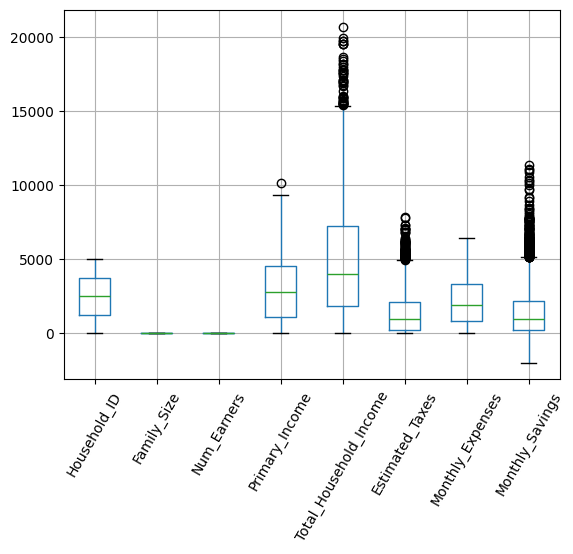

Number of records with negative monthly savings: 966


In [283]:
# Check for missing values
household.isna().sum() # no missing values

# Check for outliers
household.boxplot(rot=60)
plt.show()

# Negative in Monthly_Savings -- debts or borrowing money
print('Number of records with negative monthly savings:', (household['Monthly_Savings'] < 0).sum())

### Feature Engineering

In [284]:
# Take-home pay
household['net_income'] = household['Total_Household_Income'] - household['Estimated_Taxes']

# Annual financial headroom
household['disposable_income'] = (household['net_income'] - household['Monthly_Expenses']) * 12

# Percentage of take-home saved
household['savings_rate'] = household['Monthly_Savings'] / (household['net_income']/12)
household['savings_rate'] = round(household['savings_rate'], 2)

# Spending or Expenses ratio
household['expense_ratio'] = household['Monthly_Expenses'] / (household['net_income']/12)
household['expense_ratio'] = round(household['expense_ratio'], 2)

# Household standard of living
household['income_per_capita'] = household['Total_Household_Income'] / household['Family_Size']

# Earner productivity
household['income_per_earner'] = household['Total_Household_Income'] / household['Num_Earners']

# Income dependency risk
household['primary_income_share'] = household['Primary_Income'] / household['Total_Household_Income']

# Effective tax burden
household['tax_rate'] = household['Estimated_Taxes'] / household['Total_Household_Income']

# Composite health metric
household['financial_health_score'] = household['savings_rate'] - household['expense_ratio']

# Health Category
household['health_category'] = pd.cut(household['financial_health_score'], bins=3, labels=['Poor', 'Fair', 'Good'])

display(household.head())

,Household_ID,Country,City,Family_Size,Num_Earners,Primary_Income,Total_Household_Income,Estimated_Taxes,Monthly_Expenses,Monthly_Savings,net_income,disposable_income,savings_rate,expense_ratio,income_per_capita,income_per_earner,primary_income_share,tax_rate,financial_health_score,health_category
0,1,India,Mumbai,5,3,1032.29,2132.95,213.30,611.63,1308.02,1919.65,15696.24,8.18,3.82,426.590000,710.983333,0.483973,0.100002,4.36,Good
1,2,UK,London,2,1,5316.57,5316.57,1329.14,2240.25,1747.18,3987.43,20966.16,5.26,6.74,2658.285000,5316.570000,1.000000,0.250000,-1.48,Good
2,3,Brazil,Sao Paulo,6,3,827.81,2241.32,336.20,1111.05,794.07,1905.12,9528.84,5.00,7.00,373.553333,747.106667,0.369340,0.150001,-2.00,Fair
3,4,Germany,Munich,4,1,5139.02,5139.02,1798.66,2922.76,417.61,3340.36,5011.20,1.50,10.50,1284.755000,5139.020000,1.000000,0.350001,-9.00,Fair
4,5,USA,New York,4,3,4506.74,9624.55,2598.63,2910.88,4115.04,7025.92,49380.48,7.03,4.97,2406.137500,3208.183333,0.468255,0.270000,2.06,Good


#### Check new features

In [285]:
# Check for missing values in the new features
print(household.isna().sum(), '\n')

# Remove missing rows
# household[household['savings_rate'].isna()]
household = household.dropna(subset=['savings_rate'])
print('Shape after data cleaning:', household.shape)

Household_ID               0
Country                    0
City                       0
Family_Size                0
Num_Earners                0
Primary_Income             0
Total_Household_Income     0
Estimated_Taxes            0
Monthly_Expenses           0
Monthly_Savings            0
net_income                 0
disposable_income          0
savings_rate              15
expense_ratio             15
income_per_capita          0
income_per_earner          0
primary_income_share      15
tax_rate                  15
financial_health_score    15
health_category           15
dtype: int64 

Shape after data cleaning: (4985, 20)


### Explanortory Data Analysis

#### Household income distribution - How is household income distributed globally, and which countries have the highest and lowest earning households?

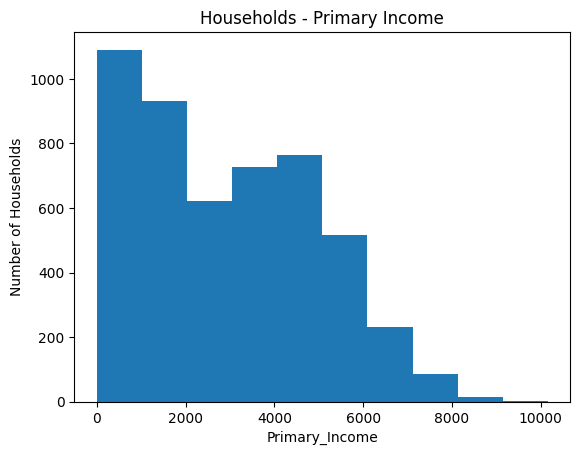

Country
Brazil     1615.567087
Germany    4341.201167
India       811.385644
UK         4291.781389
USA        4039.024344
Name: Primary_Income, dtype: float64 



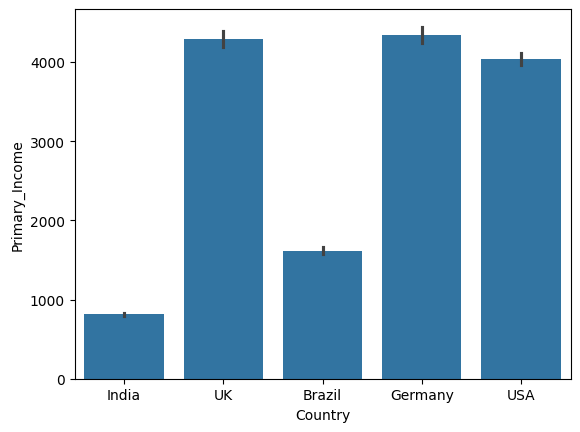

In [286]:
# Households vs Income
plt.hist(household['Primary_Income'])
plt.xlabel('Primary_Income')
plt.ylabel('Number of Households')
plt.title('Households - Primary Income')
plt.show()

# Mean Primary_Income by Country
print(household.groupby('Country')['Primary_Income'].mean(), '\n')
sns.barplot(x='Country', y='Primary_Income', data=household, estimator='mean', errorbar=('ci', 95))
plt.show()

#### Households vs saving rate and expense rate?

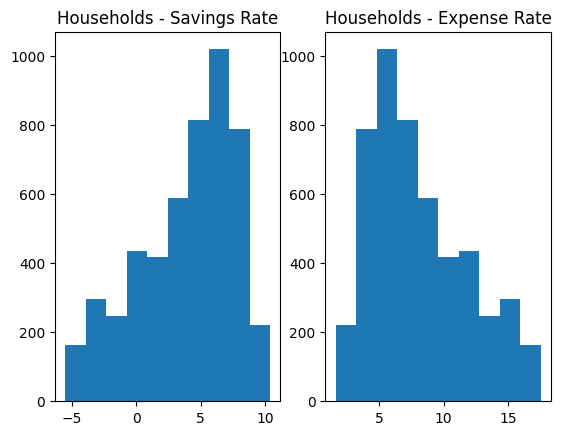

In [287]:
# Households vs Savings Rate & Expense Rate
fig, ((ax0, ax1)) = plt.subplots(nrows=1, ncols=2)

ax0.hist(household['savings_rate'])
ax0.set_title('Households - Savings Rate')
ax1.hist(household['expense_ratio'])
ax1.set_title('Households - Expense Rate')
plt.show()

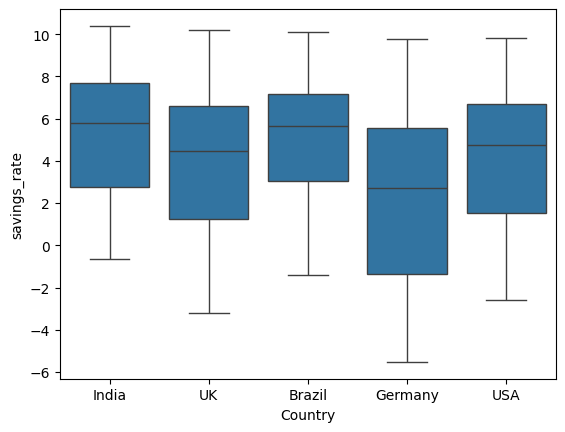

In [288]:
# Saving Rate by Country
sns.boxplot(x='Country', y='savings_rate', data=household)
plt.show()

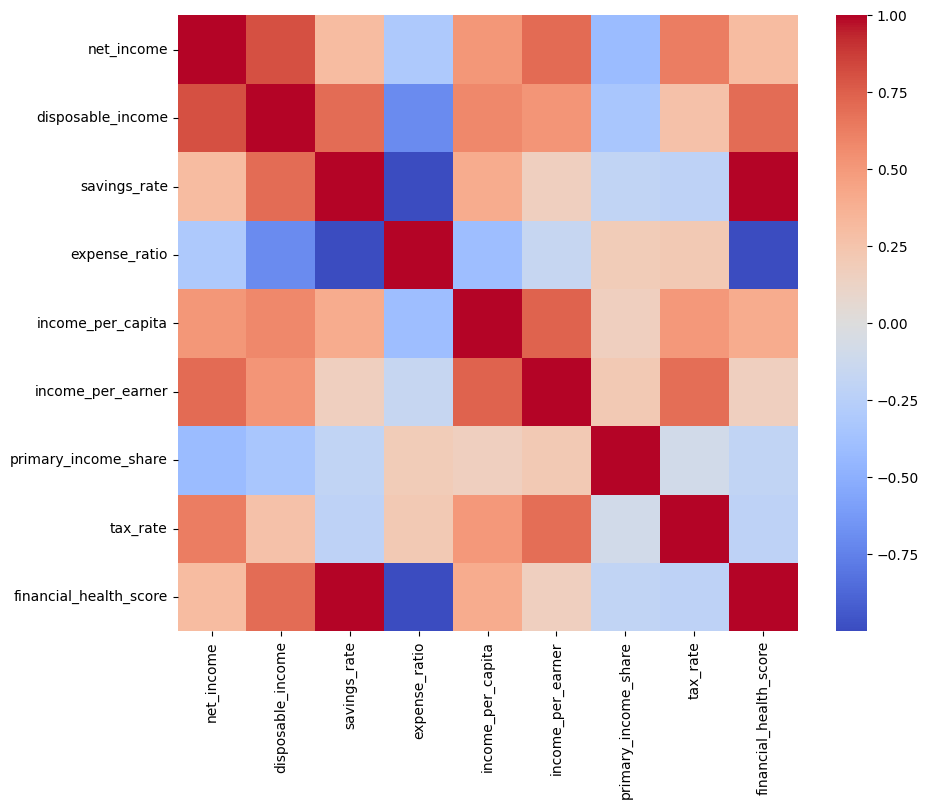

In [289]:
household_fitered = household[['net_income', 'disposable_income', 'savings_rate', 'expense_ratio', 'income_per_capita', 'income_per_earner', 'primary_income_share', 'tax_rate', 'financial_health_score']]

household_corr_matrix = household_fitered.corr()

plt.figure(figsize = (10,8))
sns.heatmap(household_corr_matrix, cmap = 'coolwarm')
plt.show()

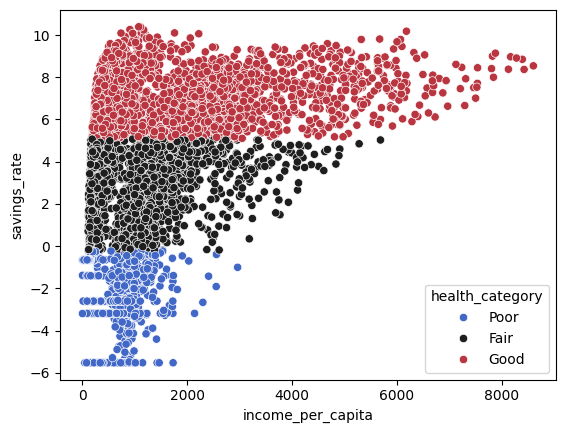

In [290]:
# Income per capita vs Savings rate
sns.scatterplot(x='income_per_capita', y='savings_rate', data=household, hue='health_category', palette='icefire')
plt.show()

#### Does having more earners in a household affect income per capita?

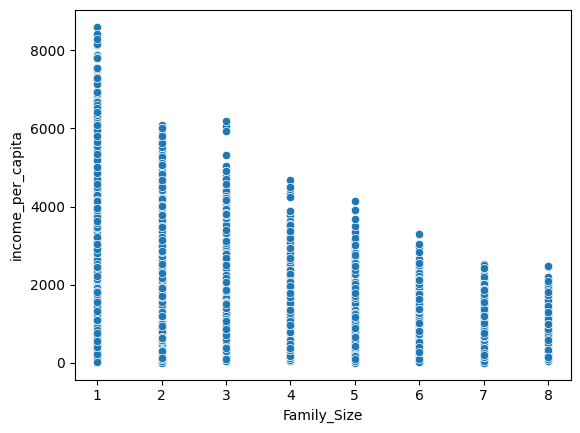

In [236]:
# Family size vs Income per capita
sns.scatterplot(x='Family_Size', y='income_per_capita', data=household)
plt.show()

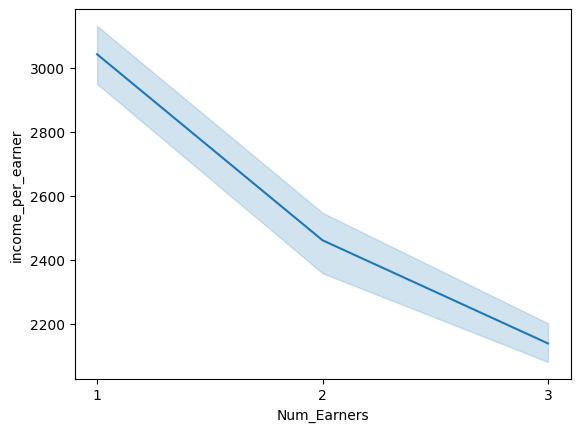

In [237]:
# Income per earner vs Number of earners
sns.lineplot(y="income_per_earner", x="Num_Earners", data=household)
plt.xticks([1, 2, 3])
plt.show()
# number of earners increases, earners productivity decreases

### Hypothesis Testing

#### Is there a statistically significant difference in savings rates across countries — or is the variation just random noise?

In [291]:
# One-Way ANOVA is a statistical test used to check if there are significant differences between the means of three or more groups i.e analysis of variance

# H0: Savings rate same across all countries 
# H1: Savings rate differs across all countries 

alpha = 0.05  #default 5%

groups = [
    group['savings_rate'].dropna()
    for _, group in household.groupby('Country')
]

f_statistic, p_value = f_oneway(*groups)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

# p_value < alpha --> reject null hypothesis
# Savings rate differs across all countries

F-statistic: 120.67980967634377
P-value: 1.9833817472539703e-98


#### Does larger families have lower standard of living (income_per_capita)?

In [293]:
# Pearson Correlation Coefficient - a statistical measure that evaluates the strength and direction of the linear relationship between two continuous variables.

# Hypothesis: Larger families have lower income_per_capita

correlation, pvalue = pearsonr(household['Family_Size'], household['income_per_capita'])
print('Correlation: ', correlation)
# Family_Size and income_per_capita are inversely correlation

Correlation:  -0.4935997056968756


#### Does multiple earners households have different spending rate?

In [292]:
# Wilcoxon Mann Whitney (Mann Whitney U) test - a non-parametric statistical test used to compare differences between two independent groups - works on unpaired data

# Hypothesis: Single-earner vs multi-earner households have different expense_ratios

household['single_multi_earners'] = np.where(household['Num_Earners'] == 1, 'Single', 'Multi')

earners_vs_expense = household[['single_multi_earners', 'expense_ratio']]

earners_vs_expense_wide = earners_vs_expense.pivot(columns='single_multi_earners', values='expense_ratio')

wmu_test = pingouin.mwu(x=earners_vs_expense_wide['Single'], y=earners_vs_expense_wide['Multi'], alternative='two-sided')
print(wmu_test)

         U_val alternative         p_val       RBC      CLES
MWU  3408720.0   two-sided  4.542318e-39  0.226048  0.613024


### OLS Regression

#### What drives monthly savings - Quantify the independent effect of income, family size, number of earners and expenses.

In [294]:
# Predict Monthly_Savings from Family_Size, Num_Earners, net_income, expense_ratio, Country dummies. 
# Report R², coefficients, confidence intervals.

ols_mdl = ols('Monthly_Savings ~ Family_Size + Num_Earners + net_income + expense_ratio + C(Country)', data=household).fit()
print(ols_mdl.summary())

                            OLS Regression Results                            
Dep. Variable:        Monthly_Savings   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     5554.
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:59:47   Log-Likelihood:                -38522.
No. Observations:                4985   AIC:                         7.706e+04
Df Residuals:                    4976   BIC:                         7.712e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              1137.48

* Model explains ~89.9% of the variation in Monthly Savings.
* net_income: Every 1 unit increase in net income increases monthly savings by ~0.66 units.
* expense_ratio: A 1-unit increase in expense ratio reduces savings by ~124 units.
* Family_Size: Each additional family member reduces savings by ~149 units.
* Num_Earners: Effect is not statistically significant (p = 0.302)
* Countries: India households save ~193 more than reference country. Germany households save ~976 less than others, UK households save ~797 less than others, USA households save ~702 less than others.

## Supervised Machine Learning

### Preprocessing Pipeline for Classification

#### OneHotEncoder for Country/City. StandardScaler for numerics unfeatured columns. Fit on only train data to avoid data leakage.

In [303]:
# train-test split
X = household[['Country', 'City', 'Family_Size', 'Num_Earners', 'Primary_Income', 'Total_Household_Income', 'Estimated_Taxes', 'Monthly_Expenses', 'Monthly_Savings']]
y = household['health_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing pipeline - OneHotEncoder and StandardScaler
categorical_features = ['Country', 'City']
numerical_features = ['Family_Size', 'Num_Earners', 'Primary_Income', 'Total_Household_Income', 'Estimated_Taxes', 'Monthly_Expenses', 'Monthly_Savings']

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=0.05), categorical_features),
    ("num", StandardScaler(), numerical_features)
])

pipeline = Pipeline([('preprocessor', preprocessor)])

X_train_processed = pipeline.fit_transform(X_train) # fit on only train data to avoid data leakage
X_test_processed = pipeline.transform(X_test)

print("X-train shape:", X_train_processed.shape)
print("X-test shape:", X_test_processed.shape)

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("y-train shape:", y_train_encoded.shape)
print("y-test shape:", y_test_encoded.shape)

X-train shape: (3988, 20)
X-test shape: (997, 20)
y-train shape: (3988,)
y-test shape: (997,)


### Classification model to predict health category

#### Logistic Regression - Random Forest - XGBoost. Cross-validation (cv=5). Confusion matrix, classification report, ROC-AUC. Feature importance bar chart.

* Can we accurately predict whether a household will fall into Low, Medium or High financial health — before knowing their savings or expenses?
* Which household characteristics are the strongest predictors of financial health — is it income, family size, tax burden, or spending behaviour?


Processing: Logistic Regression
CV Mean Accuracy: 0.9717

Classification Report:
              precision    recall  f1-score   support

        Fair       0.98      0.93      0.95       334
        Good       0.97      1.00      0.98       505
        Poor       0.94      0.97      0.96       158

    accuracy                           0.97       997
   macro avg       0.97      0.97      0.97       997
weighted avg       0.97      0.97      0.97       997

ROC-AUC Score (OvR): 0.9984


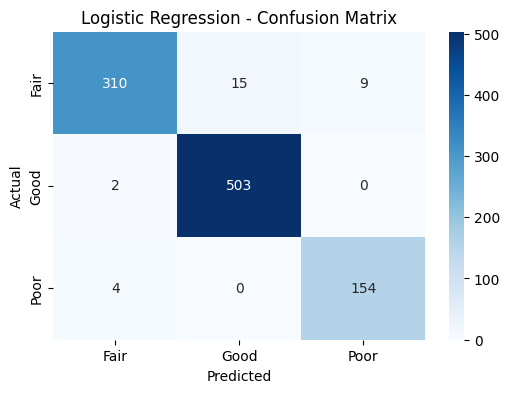

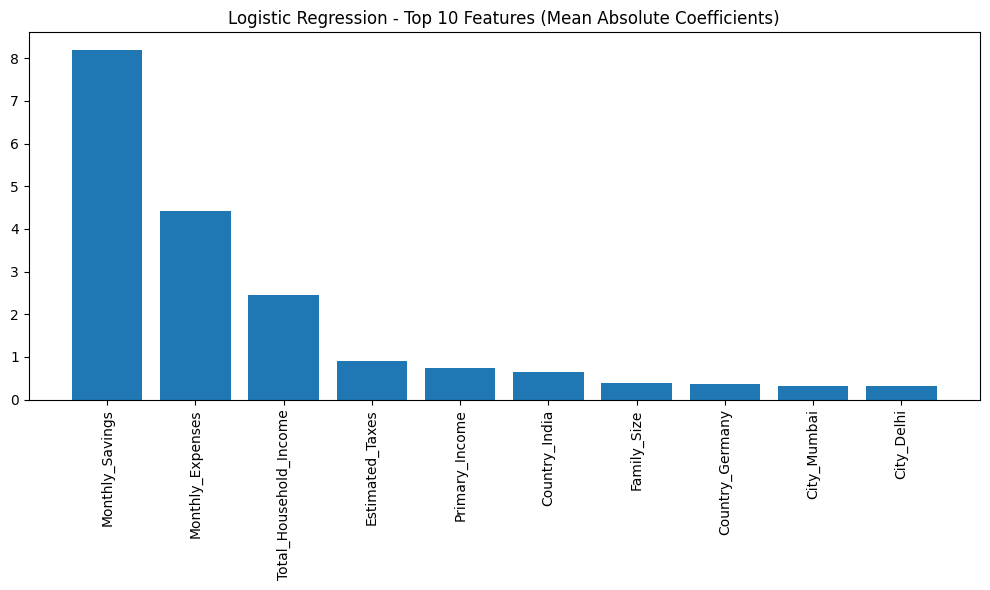


Processing: Random Forest Classifier
CV Mean Accuracy: 0.9782

Classification Report:
              precision    recall  f1-score   support

        Fair       0.95      0.94      0.95       334
        Good       0.97      0.97      0.97       505
        Poor       0.98      1.00      0.99       158

    accuracy                           0.96       997
   macro avg       0.97      0.97      0.97       997
weighted avg       0.96      0.96      0.96       997

ROC-AUC Score (OvR): 0.9974


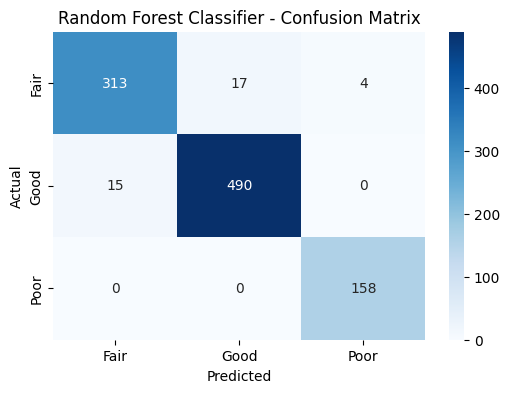

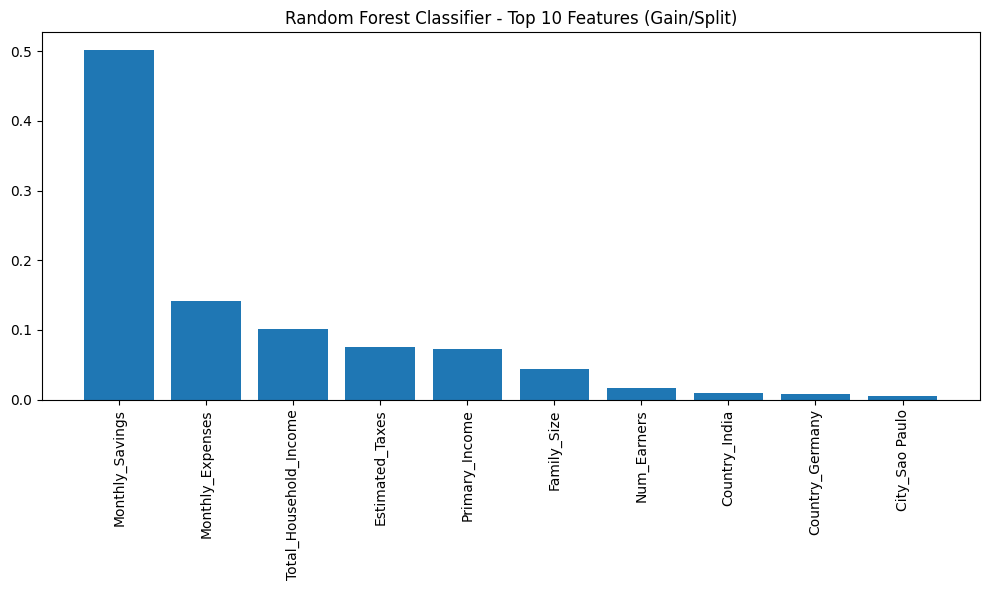


Processing: XGBoost
CV Mean Accuracy: 0.9860

Classification Report:
              precision    recall  f1-score   support

        Fair       0.97      0.95      0.96       334
        Good       0.97      0.98      0.98       505
        Poor       0.98      0.99      0.98       158

    accuracy                           0.97       997
   macro avg       0.97      0.97      0.97       997
weighted avg       0.97      0.97      0.97       997

ROC-AUC Score (OvR): 0.9991


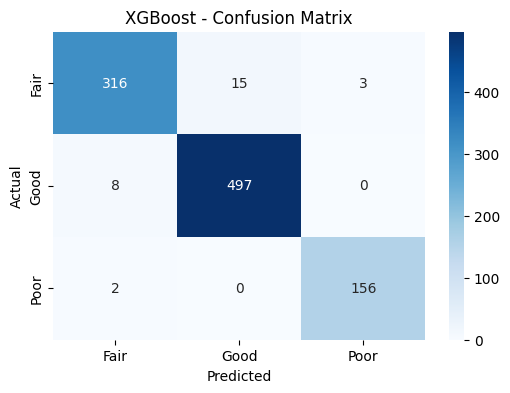

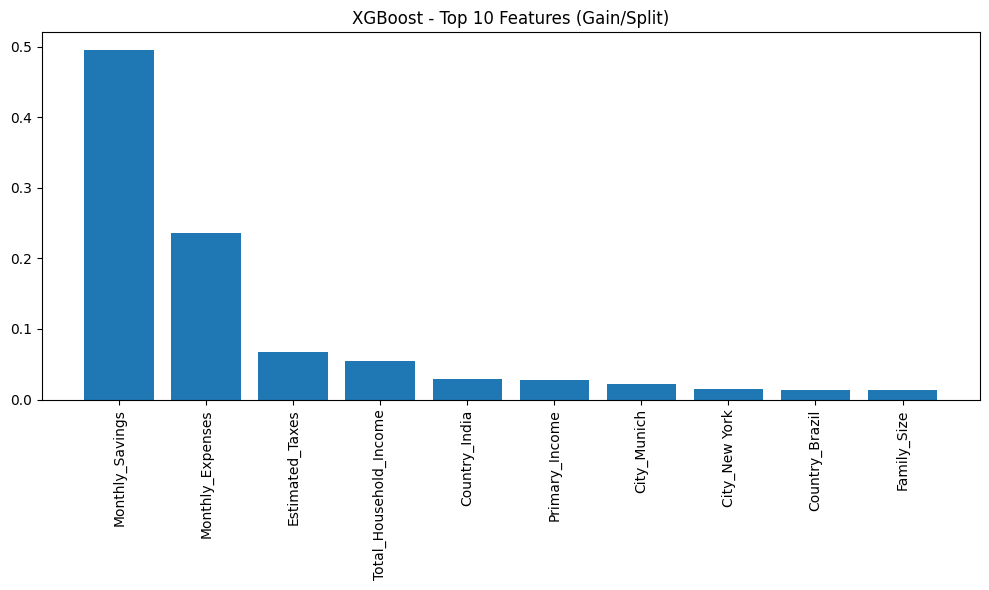

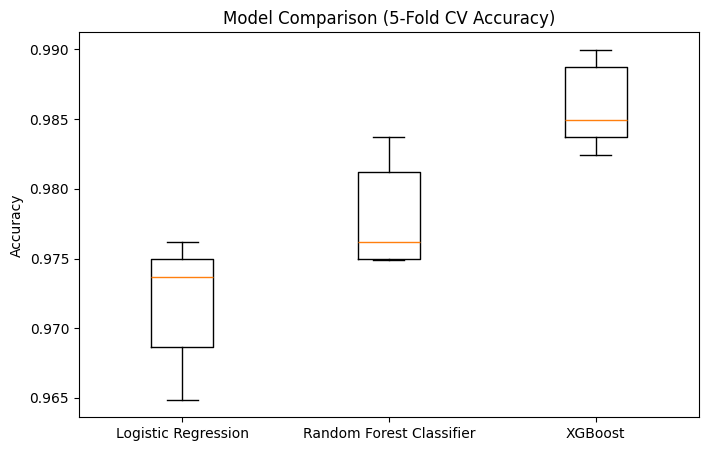

In [299]:
seed = 123
models = {'Logistic Regression': LogisticRegression(max_iter=1000, random_state=seed),
         "Random Forest Classifier": RandomForestClassifier(n_estimators=200, random_state=42), 
         "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)}

results = []

# Get the column names generated by the ColumnTransformer
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Clean up names
clean_feature_names = [name.split('__')[-1] for name in feature_names]

# Define Models
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Processing: {name}")
    print(f"{'='*40}")
    
    # --- A. Cross-Validation (cv=5) ---
    kf = KFold(n_splits=5, random_state=seed, shuffle=True)
    cv_scores = cross_val_score(model, X_train_processed, y_train_encoded, cv=kf, scoring='accuracy')
    results.append(cv_scores)
    
    print(f"CV Mean Accuracy: {cv_scores.mean():.4f}")
    
    # --- B. Fit on Full Training Data ---
    model.fit(X_train_processed, y_train_encoded)
    
    # --- C. Predictions on Test Data ---
    y_pred = model.predict(X_test_processed)
    
    # --- D. Classification Report ---
    print("\nClassification Report:")
    # Use le.classes_ to get original 'Poor', 'Fair', 'Good' labels back
    print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))
    
    # --- E. ROC-AUC Score ---
    # One-vs-Rest for multiclass
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_processed)
        roc_auc = roc_auc_score(y_test_encoded, y_proba, multi_class='ovr')
        print(f"ROC-AUC Score (OvR): {roc_auc:.4f}")
    
    # --- F. Confusion Matrix ---
    cm = confusion_matrix(y_test_encoded, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    # --- G. Feature Importance Bar Chart ---
    plt.figure(figsize=(10, 6))
    
    if name == "Logistic Regression":
        # For LR, take the mean of absolute coefficients across classes
        importances = np.mean(np.abs(model.coef_), axis=0)
        title_suffix = "(Mean Absolute Coefficients)"
    else:
        # For Tree models
        importances = model.feature_importances_
        title_suffix = "(Gain/Split)"

    # Sort features by importance
    indices = np.argsort(importances)[::-1]
    
    # Plot Top 10 features
    top_n = 10
    plt.title(f'{name} - Top {top_n} Features {title_suffix}')
    plt.bar(range(top_n), importances[indices[:top_n]], align='center')
    plt.xticks(range(top_n), [clean_feature_names[i] for i in indices[:top_n]], rotation=90)
    plt.tight_layout()
    plt.show()

# Final Boxplot Comparison
plt.figure(figsize=(8, 5))
plt.boxplot(results, tick_labels=models.keys())
plt.title('Model Comparison (5-Fold CV Accuracy)')
plt.ylabel('Accuracy')
plt.show()

**XGBoost** model is the best performer. It offers the best balance of high accuracy, perfect class separation (ROC-AUC), and generalization to new data.

* Highest Cross-Validation Score (0.97): XGBoost is more stable and consistent.
* Best ROC-AUC (0.9991): nearly perfect
* Best Balance: XGBoost maintains high precision and recall across all classes without the slight overfitting signs shown by Random Forest.

### SHAP explainability

#### What causes a household to fall into poor health?

Beeswarm for class: Poor


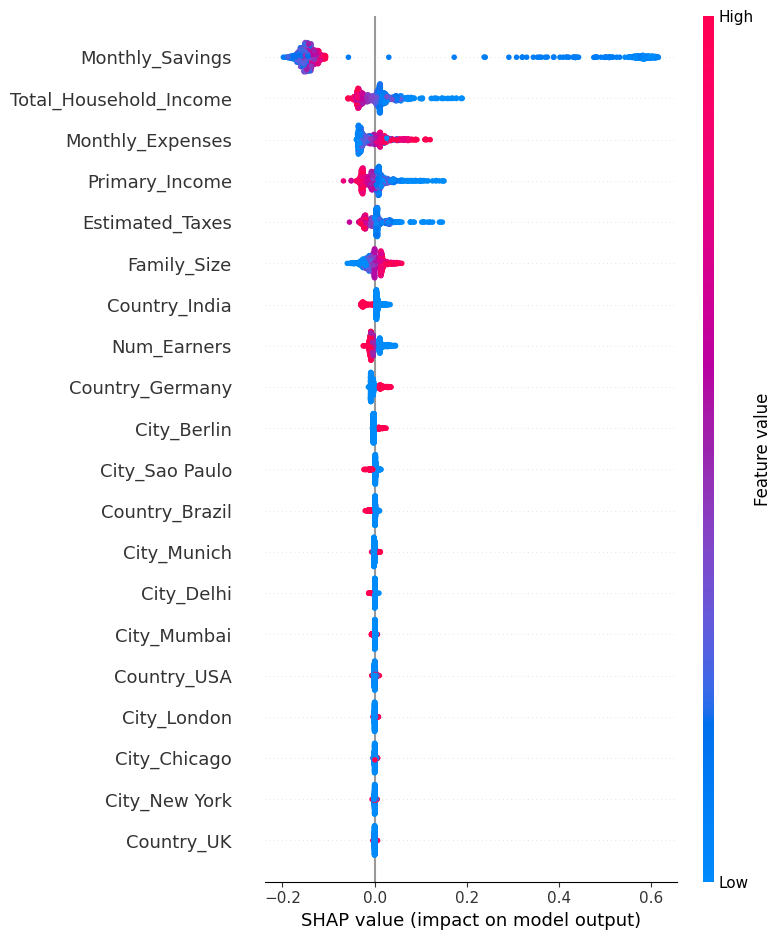

In [305]:
rf_model = models['Random Forest Classifier']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_processed)

if isinstance(shap_values, list):
    shap_values_fixed = shap_values
else:
    # newer SHAP versions return (samples, features, classes)
    shap_values_fixed = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

print('Beeswarm for class: Poor')
shap.summary_plot(shap_values_fixed[2], X_test_processed, feature_names=clean_feature_names)

* Monthly savings is the primary risk factor. Low savings is the strongest indicator of poor household health.
* Income is a strong protective factor against Poor classification.
* High spending burden increases financial stress → model associates it with Poor health.
* Lower primary income increases risk.
* Higher taxes slightly push toward Poor.

### Preprocessing for Regression

In [251]:
# train-test split
X_rg = household[['Country', 'City', 'Family_Size', 'Num_Earners', 'Primary_Income', 'Total_Household_Income', 'Estimated_Taxes', 'Monthly_Expenses']]
y_rg = household['Monthly_Savings']

X_train_rg, X_test_rg, y_train_rg, y_test_rg = train_test_split(X_rg, y_rg, test_size=0.2, random_state=42)

# Preprocessing pipeline - OneHotEncoder and StandardScaler
categorical_features = ['Country', 'City']
numerical_features = ['Family_Size', 'Num_Earners', 'Primary_Income', 'Total_Household_Income', 'Estimated_Taxes', 'Monthly_Expenses']

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numerical_features)
])

pipeline = Pipeline([('preprocessor', preprocessor)])

X_train_processed_rg = pipeline.fit_transform(X_train_rg) # fit on only train data to avoid data leakage
X_test_processed_rg = pipeline.transform(X_test_rg)

print("X-train shape:", X_train_processed_rg.shape)
print("X-test shape:", X_test_processed_rg.shape)

X-train shape: (3988, 19)
X-test shape: (997, 19)


### Regression model to predict monthly savings

#### Linear Regression vs Ridge vs Random Forest Regressor. MAE, RMSE, R². Which model wins and why?

* How accurately can we predict a household's monthly savings?

In [256]:
seed = 123
models_rg = {'Linear Regression': LinearRegression(),
         "Ridge": Ridge(alpha=1.0), 
         "Random Forest Regressor": RandomForestRegressor(n_estimators=200,max_depth=10,random_state=42)
        }

results_rg = []
predictions = {}
residuals_dict = {}

# Define Models
for name_rg, model_rg in models_rg.items():
    model_rg.fit(X_train_processed_rg, y_train_rg)
    y_pred_rg = model_rg.predict(X_test_processed_rg)

    mae = mean_absolute_error(y_test_rg, y_pred_rg)
    rmse = np.sqrt(mean_squared_error(y_test_rg, y_pred_rg))
    r2 = r2_score(y_test_rg, y_pred_rg)
    
    residuals = y_test_rg - y_pred_rg
    predictions[name_rg] = y_pred_rg
    residuals_dict[name_rg] = residuals

    results_rg.append({'Model':name_rg, 'MAE':round(mae, 2), 'RMSE':round(rmse, 2), 'R²':round(r2, 4)})

    print(f'\n{name_rg}')
    print('-' * 30)
    print('MAE :', round(mae, 2))
    print('RMSE:', round(rmse, 2))
    print('R²  :', round(r2, 4))

results_df = pd.DataFrame(results_rg)
display(results_df)


Linear Regression
------------------------------
MAE : 0.0
RMSE: 0.01
R²  : 1.0

Ridge
------------------------------
MAE : 7.16
RMSE: 9.37
R²  : 1.0

Random Forest Regressor
------------------------------
MAE : 86.54
RMSE: 131.07
R²  : 0.9941


,Model,MAE,RMSE,R²
0,Linear Regression,0.00,0.01,1.0000
1,Ridge,7.16,9.37,1.0000
2,Random Forest Regressor,86.54,131.07,0.9941


#### Regression metrics plot

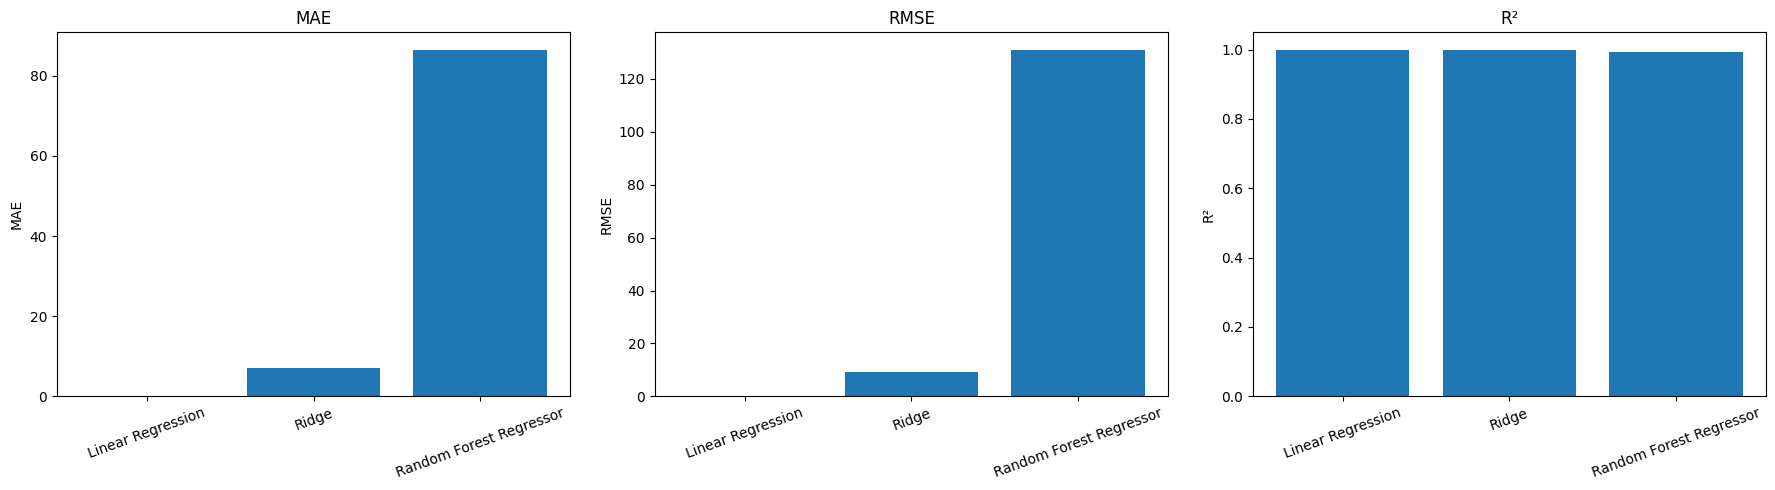

In [253]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['MAE', 'RMSE', 'R²']

for ax, metric in zip(axes, metrics):
    ax.bar(results_df['Model'], results_df[metric])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

#### Correlation

In [254]:
corr = household.select_dtypes(include='number').corr()
corr['Monthly_Savings'].sort_values(ascending=False)

Monthly_Savings           1.000000
disposable_income         1.000000
net_income                0.811590
Total_Household_Income    0.775551
savings_rate              0.695723
financial_health_score    0.695723
Estimated_Taxes           0.658926
Primary_Income            0.637272
income_per_capita         0.582580
income_per_earner         0.523122
Num_Earners               0.324852
tax_rate                  0.273057
Monthly_Expenses          0.189303
Household_ID             -0.018664
Family_Size              -0.048528
primary_income_share     -0.343263
expense_ratio            -0.695723
Name: Monthly_Savings, dtype: float64

#### Residual plot

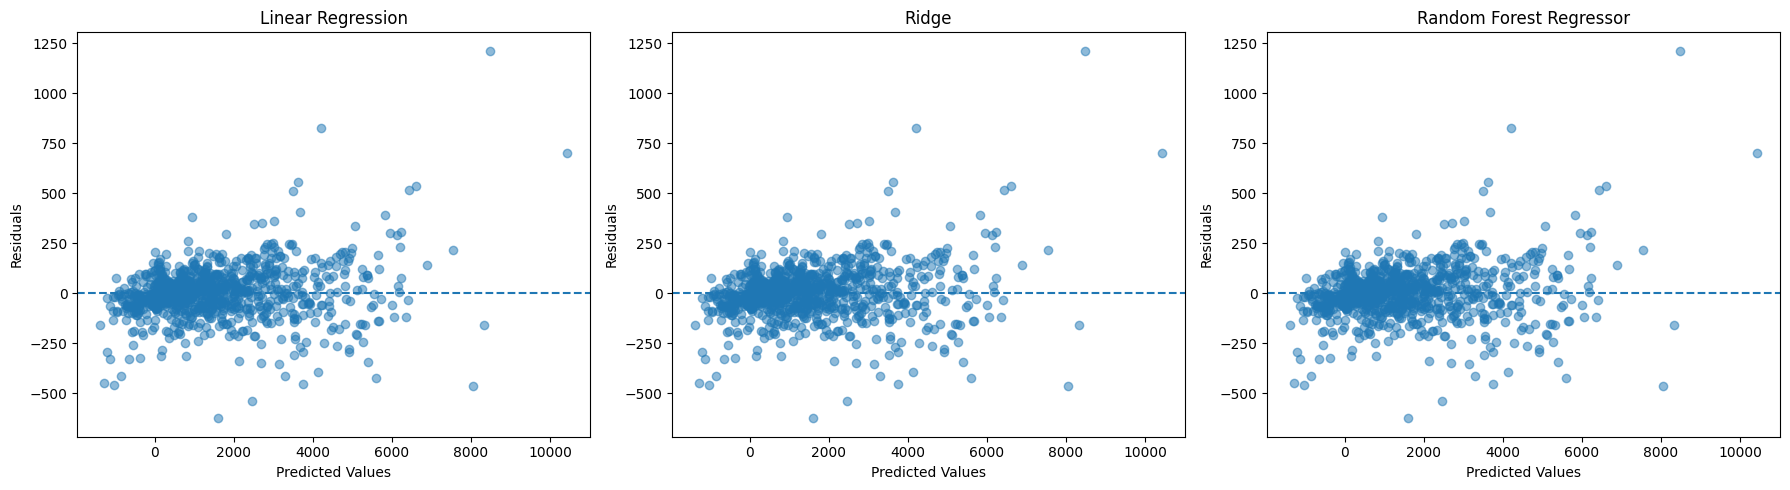

In [257]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name_rg, y_pred_rg) in zip(axes, predictions.items()):
    residuals = residuals_dict[name]
    ax.scatter(y_pred, residuals, alpha=0.5)
    ax.axhline(y=0, linestyle='--')
    ax.set_title(name_rg)
    ax.set_xlabel("Predicted Values")
    ax.set_ylabel("Residuals")

plt.tight_layout()
plt.show()

#### Actual vs Predicted Plot

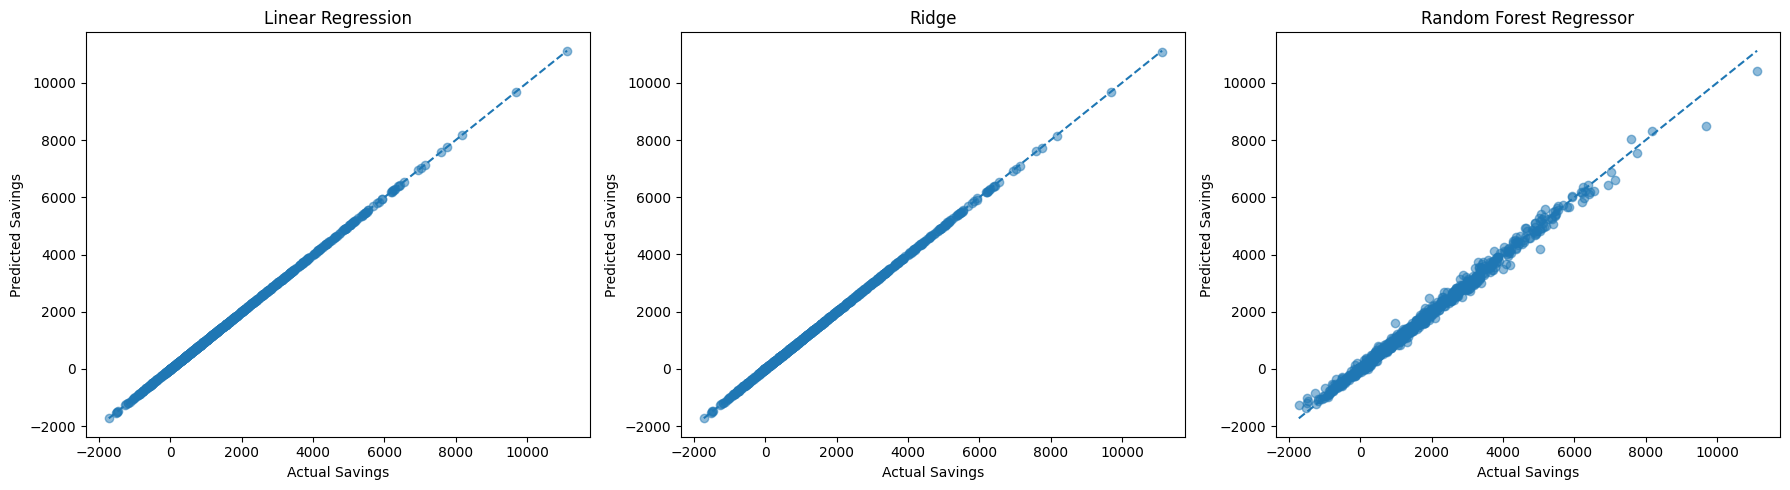

In [259]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name_rg, y_pred_rg) in zip(axes, predictions.items()):
    ax.scatter(y_test_rg, y_pred_rg, alpha=0.5)
    ax.plot(
        [y_test_rg.min(), y_test_rg.max()],
        [y_test_rg.min(), y_test_rg.max()],
        '--')
    ax.set_title(name_rg)
    ax.set_xlabel("Actual Savings")
    ax.set_ylabel("Predicted Savings")

plt.tight_layout()
plt.show()

In [247]:
best_model = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"Best Model: {best_model}")

Best Model: Linear Regression


Monthly Savings was found to be a deterministic function of Total Household Income, Estimated Taxes, and Monthly Expenses. Correlation analysis showed a perfect correlation (r = 1.00) between Monthly Savings and Disposable Income. Further validation demonstrated that Monthly Savings could be reconstructed almost exactly using:
Monthly Savings=Total Household Income−Estimated Taxes−Monthly Expenses

As a result, Linear Regression achieved near-perfect predictive performance (R² = 1.00), outperforming Random Forest because the underlying relationship was inherently linear.

## Unsupervised Machine Learning

### Preprocessing for K-Means

In [317]:
household_cluster = household.drop(columns=['Household_ID', 'health_category', 'single_multi_earners'])

cat_cols = ['Country', 'City']
num_cols = ['Family_Size', 'Num_Earners', 'Primary_Income', 'Total_Household_Income', 'Estimated_Taxes', 'Monthly_Expenses', 'Monthly_Savings', 'net_income', 
                  'disposable_income', 'savings_rate', 'expense_ratio', 'income_per_capita', 'income_per_earner', 'primary_income_share', 'tax_rate', 'financial_health_score']

household_encoded = pd.get_dummies(household_cluster, columns=cat_cols, drop_first=True)

scaler = StandardScaler()
household_scaled = scaler.fit_transform(household_encoded)

### Elbow Method

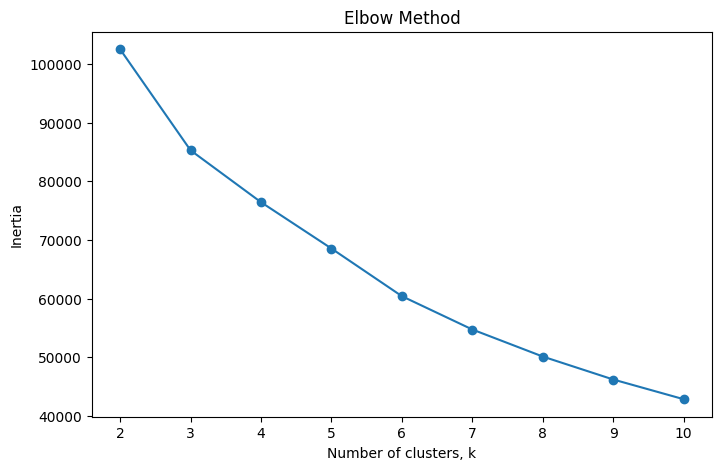

In [324]:
# Elbow Method - Detect the optimal number of k-clusters for k-means clustering

inertia = []
ks = range(2, 11)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(household_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(ks, inertia, '-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.title('Elbow Method')
plt.show()

From the above Elbow Method plot, number of clusters should be 6 or 7

### Silhouette Score

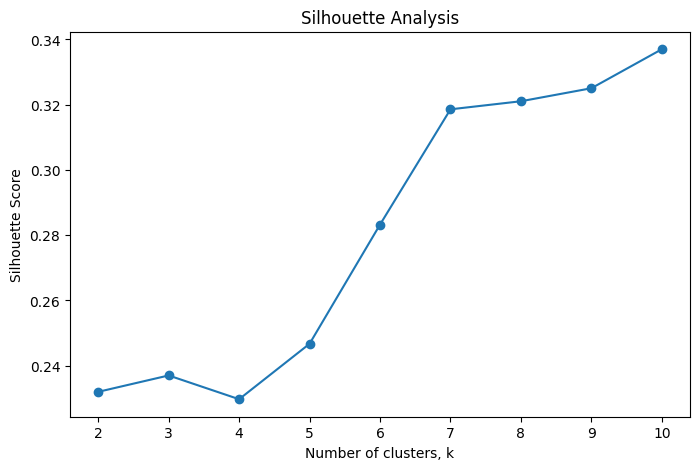

In [323]:
# Silhouette Score - metric used to evaluate the quality and performance of clustering algorithms, such as K-Means.

sil_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(household_scaled)
    sil_scores.append(silhouette_score(household_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(ks, sil_scores, '-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('Silhouette Score')
plt.xticks(ks)
plt.title('Silhouette Analysis')
plt.show()

From the Silhouette Analysis plot, optimal **k = 7** as it is near the elbow region, larger jump in silhouette score.

### K-Means Clustering

In [367]:
model_kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)

household['cluster'] = model_kmeans.fit_predict(household_scaled)

### PCA Visualisation

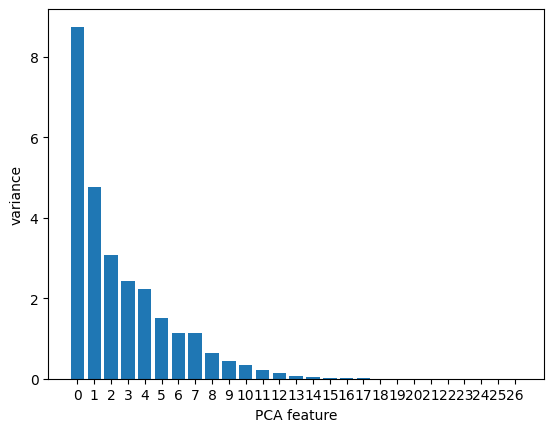

In [370]:
# Perform PCA
pca_check = PCA()
pca_check.fit(household_scaled)
features = range(pca_check.n_components_)
plt.bar(features, pca_check.explained_variance_)
plt.xlabel('PCA feature')
plt.ylabel('variance')
plt.xticks(features)
plt.show()
# significant variance is PCA features 0 and 1, n_components should be 2

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(household_scaled)
pca_household = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_household['cluster'] = household['cluster']

### Scatter Plot for K-Means Clusters

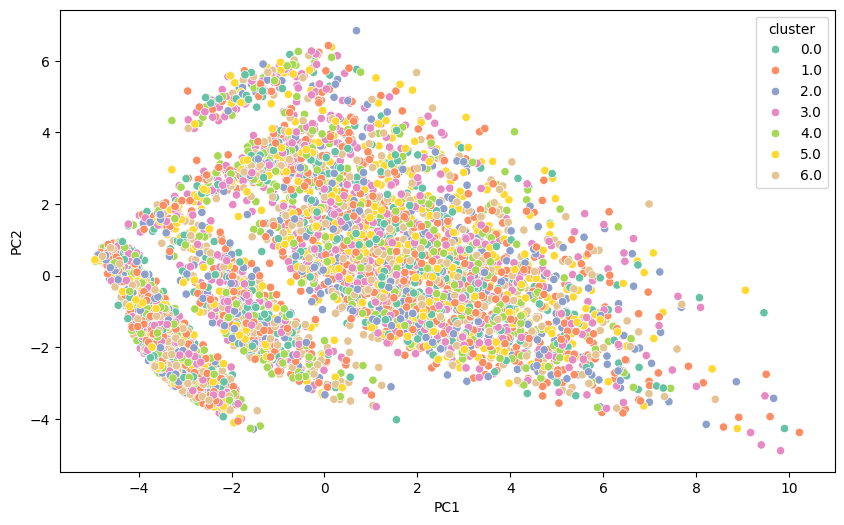

In [371]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=pca_household, x='PC1', y='PC2', hue='cluster', palette='Set2')
plt.show()

#### Do households naturally cluster into distinct financial profiles?

In [372]:
print('Silhouette Score:',  silhouette_score(household_scaled, household['cluster'])) 

Silhouette Score: 0.3185839808531652


Silhouette score shows reasonable separation between clusters.

### Cluster Profiling

#### What share of the global household population is at financial risk?

In [375]:
cluster_profile = (household.groupby('cluster').agg(
    n_households = ('Household_ID','count'),
    mean_income = ('Total_Household_Income','mean'),
    mean_savings_rate = ('savings_rate','mean'),
    mean_expense_ratio = ('expense_ratio', 'mean'),
    mean_family_size = ('Family_Size', 'mean'),
    mean_num_earners = ('Num_Earners', 'mean'),
    mean_income_per_cap = ('income_per_capita', 'mean'),
    dominant_country = ('Country', lambda x: x.value_counts().index[0])
    )
)

display(cluster_profile)

,n_households,mean_income,mean_savings_rate,mean_expense_ratio,mean_family_size,mean_num_earners,mean_income_per_cap,dominant_country
cluster,,,,,,,,
0,595,1328.730420,4.986336,7.013647,4.374790,2.070588,396.532466,India
1,932,7889.392350,5.716878,6.283133,4.271459,2.215665,2339.975789,USA
2,598,7877.818512,5.020518,6.979482,4.294314,2.187291,2355.215435,UK
3,822,3705.371825,-2.148479,14.148491,5.034063,1.777372,885.715001,USA
4,617,1361.627504,5.110729,6.889287,4.612642,2.142626,385.532409,India
5,683,8726.246852,4.453602,7.546413,4.398243,2.247438,2632.527476,Germany
6,738,2649.073821,4.774444,7.225556,4.414634,2.116531,790.874014,Brazil


In [382]:
cluster_names = {
    0: 'Low-Income Surviving Households',    # low income, high expense ratio, large families
    1: 'Affluent Mid-Savers',                # high income, modest savings, small household
    2: 'High-Income Stretched Spenders',     # high income but high expenses eat most of it
    3: 'Financially Distressed Households',  # negative savings, very high expense ratio
    4: 'Low-Income Large Families',          # low income, moderate expense ratio, slightly larger families
    5: 'High-Income Low-Efficiency Savers',  # highest income, avearge savings - lifestyle inflation only
    6: 'Emerging Market Middle Households',  # mid-low income, average savings, middle ground between low and high income clusters
}

household['segment'] = household['cluster'].map(cluster_names)

#### Country × Cluster Analysis

*  Which countries are most over-represented in the vulnerable segment?

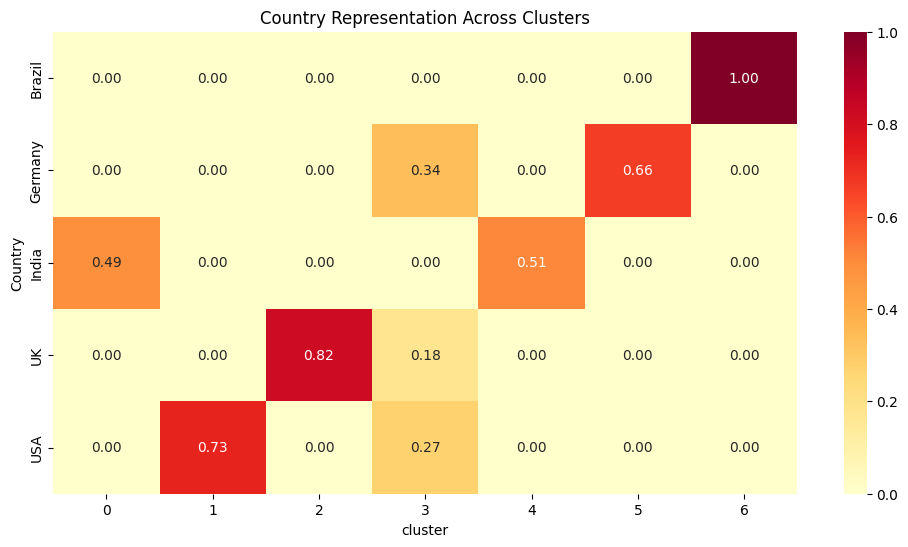

In [385]:
country_cluster = pd.crosstab(household['Country'], household['cluster'], normalize='index')

plt.figure(figsize=(12,6))

sns.heatmap(country_cluster, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Country Representation Across Clusters')
plt.show()

#### Family Structure Analysis

* Which family structures are most over-represented in the vulnerable segment?

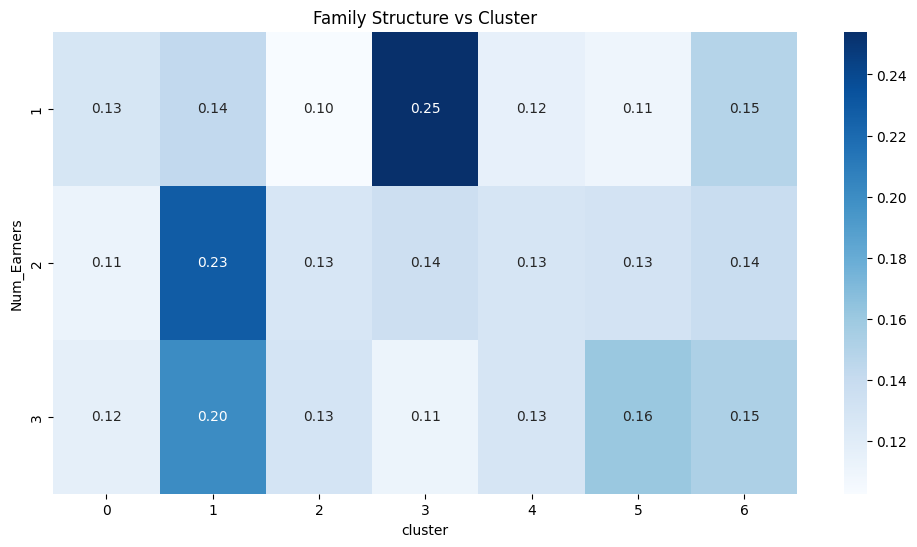

In [389]:
family_cluster = pd.crosstab(household['Num_Earners'], household['cluster'], normalize='index')

plt.figure(figsize=(12,6))

sns.heatmap(family_cluster, annot=True, cmap='Blues', fmt='.2f')
plt.title('Family Structure vs Cluster')
plt.show()